## Binary classification using Deep Neural Networks Example: Classify movie reviews into positive" reviews and "negative" reviews, just based on the text content of the reviews. Use IMDB dataset.

In [24]:
import pandas as pd

In [25]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [26]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder() # Remember this line

df['sentiment'] = encoder.fit_transform(df['sentiment'])
df['sentiment']

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [27]:
X = df['review'].values
y = df['sentiment'].values

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [29]:
VOCAB_SIZE = 10000
MAX_LEN = 200

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words = VOCAB_SIZE, oov_token= '<OOV>') # remember this num_words

tokenizer.fit_on_texts(X_train)  #remember this 
X_train_seq = tokenizer.texts_to_sequences(X_train) # Also tokenizer.texts_to_sequences
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences # here only sequence

X_train_pad = pad_sequences(X_train_seq, maxlen = MAX_LEN, padding= "post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen = MAX_LEN, padding= "post", truncating ="post")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten

model = Sequential()

model.add(Embedding(input_dim = VOCAB_SIZE, output_dim = 64, input_length = MAX_LEN))
model.add(Flatten())
model.add(Dense(64, activation = "relu"))
model.add(Dense(1, activation = "sigmoid"))

model.compile(optimizer="adam", loss = "binary_crossentropy", metrics = ["accuracy"])
model.build(input_shape=(None, MAX_LEN))
model.summary()

/Users/niranjan/Documents/venv/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
)

Epoch 1/10


2026-05-07 19:08:10.400582: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


985/985 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7149 - loss: 0.5160 - val_accuracy: 0.8620 - val_loss: 0.3249
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9515 - loss: 0.1399 - val_accuracy: 0.8217 - val_loss: 0.5004
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9834 - loss: 0.0566 - val_accuracy: 0.8369 - val_loss: 0.5938
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9862 - loss: 0.0572 - val_accuracy: 0.8243 - val_loss: 0.7596
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9928 - loss: 0.0289 - val_accuracy: 0.8191 - val_loss: 0.8576
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9938 - loss: 0.0249 - val_accuracy: 0.8166 - val_loss: 0.9805
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9955 - loss: 0.0170 - val_accuracy: 0.8174 - val_loss: 1.2400
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9911 - loss: 0.0341 - val_accurac

In [34]:
loss, accuracy = model.evaluate(X_test_pad,y_test,verbose=1)
print("Accuracy of test : ", accuracy)
print("Loss of test : ", loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8168 - loss: 1.4204
Accuracy of test :  0.8167999982833862
Loss of test :  1.423508882522583


In [36]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


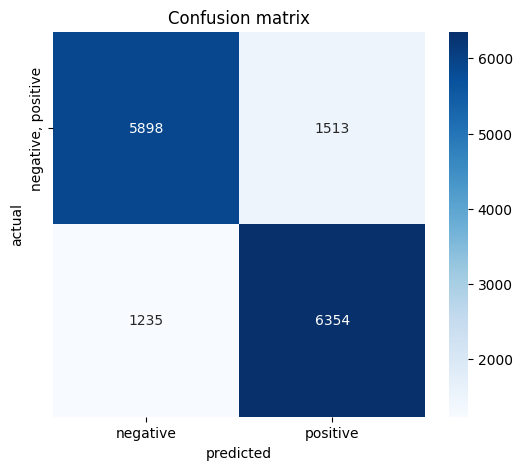

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (6,5))
sns.heatmap(cm,annot=True, fmt='d', cmap = 'Blues', # here remember cmap='Blues'
           xticklabels = ['negative','positive'],
           yticklabels = ['negative, positive'])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion matrix")
plt.show()

In [39]:
print(classification_report(y_test,y_pred, target_names=['negative','posititve'])) # here remember : target_names

              precision    recall  f1-score   support

    negative       0.83      0.80      0.81      7411
   posititve       0.81      0.84      0.82      7589

    accuracy                           0.82     15000
   macro avg       0.82      0.82      0.82     15000
weighted avg       0.82      0.82      0.82     15000

